# Avance 1: Análisis Exploratorio de Datos (EDA)

**Proyecto integrador** — conjunto de datos **InHARD** (índice tabular de anotaciones).

**Nombre sugerido del entregable:** `Avance1.#Equipo` (reemplazar `#Equipo`).

**Entrega:** ejecutar la libreta **de principio a fin en orden secuencial**; subir **liga al `.ipynb` en GitHub** del equipo.

---

## Qué es este avance (texto de la actividad)

Este primer avance consiste en realizar un **análisis exploratorio de datos (EDA)**, es decir, **describir los datos** mediante **técnicas estadísticas y de visualización** (análisis **univariante** y **bi/multivariante**) para enfocarse en los aspectos más relevantes, y **aplicar y justificar operaciones de preprocesamiento** relacionadas con **valores faltantes**, **atípicos** y **alta cardinalidad**, incluyendo **conclusiones** que identifiquen **tendencias o relaciones importantes**.

---

## Metodología: CRISP-ML(Q)

El EDA apoya la fase de **comprensión de los datos** dentro de **CRISP-ML(Q)** y prepara decisiones de **modelado** y **evaluación** (por ejemplo, métricas robustas al desequilibrio y validación por sesión).

### Preguntas guía que aborda esta libreta

- ¿Hay valores faltantes? ¿Patrones de ausencia?
- ¿Estadísticas resumidas (numéricas y categóricas)?
- ¿Valores atípicos?
- ¿Cardinalidad de categóricas?
- ¿Distribuciones sesgadas? ¿Transformaciones?
- ¿Tendencias temporales (según columnas de tiempo del índice)?
- ¿Correlación entre numéricas? ¿Relación con la variable objetivo?
- ¿Distribución por categorías (bivariado)?
- ¿Normalización de imágenes? (nota: esta entrega es tabular; se comenta el caso RGB)
- ¿Desequilibrio de clases en la objetivo?


## Variable objetivo

**Definida para este equipo (HAR sobre InHARD):** `Meta_action_label` (clasificación multiclase).

**Alternativas válidas:** `Action_label` (acción fina) o `Duration_sec` (regresión). Cambiar `VARIABLE_OBJETIVO` en la celda de configuración si el problema del equipo es otro.


## 1. Setup

**Por qué:** fijar semillas, estilos y constantes asegura **reproducibilidad** y figuras con **títulos y ejes claros** (rúbrica).


In [1]:
# Configuración global y librerías (PEP 8).
from __future__ import annotations

import warnings
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

VARIABLE_OBJETIVO = 'Meta_action_label'

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    try:
        plt.style.use('seaborn-whitegrid')
    except OSError:
        plt.style.use('ggplot')

sns.set_theme(style='whitegrid', context='talk', font_scale=0.95)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print('Setup listo. VARIABLE_OBJETIVO =', repr(VARIABLE_OBJETIVO))


Setup listo. VARIABLE_OBJETIVO = 'Meta_action_label'


## 2. Auditoría de la estructura de datos

**Por qué:** documentar `shape`, `info`, `describe` (numérico y categórico), **nulos** y **tipos** antes de visualizar evita conclusiones erróneas por datos mal ingestados.


In [2]:
def resolver_raiz_inhard(inicio: Optional[Path] = None) -> Path:
    inicio = inicio or Path.cwd().resolve()
    for directorio in [inicio, *inicio.parents]:
        candidato = directorio / 'data_sample' / 'InHARD-master'
        if candidato.is_dir():
            return candidato
    raise FileNotFoundError(
        'No se encontró data_sample/InHARD-master. '
        'Use CWD en la raíz del repo o en esta carpeta.'
    )


RAIZ_INHARD = resolver_raiz_inhard()
RUTA_CSV = RAIZ_INHARD / '01-InHARD' / 'Segmented' / 'InHARD.csv'
df = pd.read_csv(RUTA_CSV)
if '' in df.columns:
    df = df.rename(columns={'': 'indice_exportacion'})

print('Ruta:', RUTA_CSV)
print('shape (filas, columnas):', df.shape)


Ruta: /Users/cpanoh/Documents/cpano-98-local/GitHub/AI-Co-Pilot-for-the-Production-Floor-See-Guide-Improve/data_sample/InHARD-master/01-InHARD/Segmented/InHARD.csv
shape (filas, columnas): (5303, 15)


In [3]:
display(df.head(10))


,Unnamed: 0,Action_end_bvh_frame,Action_end_rgb_frame,Action_end_rgb_sec,Action_label,Action_start_bvh_frame,Action_start_rgb_frame,Action_start_rgb_sec,Duration_sec,File,Meta_action_class_number,Meta_action_label,Operation,Recurrence,Subject
0,0,1071,270,9.00,[OP010] Consult sheets,324,82,2.72,6.28,P01_R01,2,Consult sheets,OP010,R01,P01
1,1,1528,385,12.84,[OP010] Catch Fixture key LARD,1343,338,11.28,1.56,P01_R01,7,Picking left,OP010,R01,P01
2,2,2247,566,18.88,[OP010] Place LARD on Profile P360-1,1647,415,13.84,5.04,P01_R01,12,Assemble system,OP010,R01,P01
3,3,3028,762,25.44,[OP010] Catch Fixation FIXA1,2776,699,23.32,2.12,P01_R01,6,Picking in front,OP010,R01,P01
4,4,3428,863,28.80,[OP010] Place FIXA1 on LARD at 160mm,3152,794,26.48,2.32,P01_R01,12,Assemble system,OP010,R01,P01
5,5,3857,971,32.40,[OP010] Catch Bolt B820,3719,936,31.24,1.16,P01_R01,7,Picking left,OP010,R01,P01
6,6,4514,1136,37.92,[OP010] Take measuring rod,4352,1096,36.56,1.36,P01_R01,8,Take measuring rod,OP010,R01,P01
7,7,4809,1211,40.40,[OP010] Take screwdriver,4685,1180,39.36,1.04,P01_R01,4,Take screwdriver,OP010,R01,P01
8,8,5304,1335,44.56,[OP010] Screw FIXA1 with B820,4904,1235,41.20,3.36,P01_R01,12,Assemble system,OP010,R01,P01
9,9,5623,1416,47.24,[OP010] Put down screwdriver,5328,1341,44.76,2.48,P01_R01,5,Put down screwdriver,OP010,R01,P01


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5303 entries, 0 to 5302
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                5303 non-null   int64  
 1   Action_end_bvh_frame      5303 non-null   int64  
 2   Action_end_rgb_frame      5303 non-null   int64  
 3   Action_end_rgb_sec        5303 non-null   float64
 4   Action_label              5303 non-null   object 
 5   Action_start_bvh_frame    5303 non-null   int64  
 6   Action_start_rgb_frame    5303 non-null   int64  
 7   Action_start_rgb_sec      5303 non-null   float64
 8   Duration_sec              5303 non-null   float64
 9   File                      5303 non-null   object 
 10  Meta_action_class_number  5303 non-null   int64  
 11  Meta_action_label         5303 non-null   object 
 12  Operation                 5303 non-null   object 
 13  Recurrence                5303 non-null   object 
 14  Subject 

In [5]:
display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,5303.0,2380.876296,1397.183952,0.00,1164.00,2360.00,3599.500000,4802.00
Action_end_bvh_frame,5303.0,26121.089006,18204.994487,252.00,11335.00,23696.00,37390.500000,104697.00
Action_end_rgb_frame,5303.0,6577.231378,4583.683270,64.00,2854.50,5968.00,9413.000000,26354.00
Action_end_rgb_sec,5303.0,219.460592,152.942317,2.12,95.24,199.12,314.079995,879.36
Action_start_bvh_frame,5303.0,25833.565529,18175.053228,29.00,11035.00,23397.00,37024.000000,103163.00
Action_start_rgb_frame,5303.0,6504.838205,4576.144748,7.00,2778.00,5891.00,9329.000000,25968.00
Action_start_rgb_sec,5303.0,217.044850,152.690887,0.24,92.70,196.56,311.280005,866.48
Duration_sec,5303.0,2.415742,1.768832,0.12,1.40,2.00,2.920000,26.96
Meta_action_class_number,5303.0,7.618141,4.022329,0.00,5.00,7.00,12.000000,14.00


In [6]:
obj_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
if obj_cols:
    display(df[obj_cols].describe(include='object').T)
else:
    print('Sin columnas object para describe categórico.')


,count,unique,top,freq
Action_label,5303,103,[OP000] No action,500
File,5303,38,P06_R01,198
Meta_action_label,5303,14,Assemble system,1378
Operation,5303,8,OP030,1187
Recurrence,5303,4,R01,2205
Subject,5303,16,P08,624


In [7]:
ausentes = df.isna().sum().sort_values(ascending=False)
ausentes_pct = (100 * ausentes / len(df)).round(2)
tabla = pd.DataFrame({'nulos': ausentes, 'porcentaje': ausentes_pct})
tabla = tabla[tabla['nulos'] > 0]
print('Columnas con nulos:')
display(tabla if len(tabla) else 'Ninguno.')
print('\nConteo de dtypes:')
print(df.dtypes.value_counts())


Columnas con nulos:


'Ninguno.'


Conteo de dtypes:
int64      6
object     6
float64    3
Name: count, dtype: int64


## 3. Análisis univariante

**Por qué:** histogramas y boxplots revelan **asimetría**, **outliers** y escalas; barras y **cardinalidad** orientan decisiones de **encoding** y **agrupación**.


In [8]:
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'indice_exportacion']
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
if VARIABLE_OBJETIVO in df.columns and VARIABLE_OBJETIVO not in cat_cols:
    cat_cols.append(VARIABLE_OBJETIVO)
cat_cols = sorted(set(cat_cols))
print('Numéricas:', numeric_cols)
print('Categóricas:', cat_cols)


Numéricas: ['Unnamed: 0', 'Action_end_bvh_frame', 'Action_end_rgb_frame', 'Action_end_rgb_sec', 'Action_start_bvh_frame', 'Action_start_rgb_frame', 'Action_start_rgb_sec', 'Duration_sec', 'Meta_action_class_number']
Categóricas: ['Action_label', 'File', 'Meta_action_label', 'Operation', 'Recurrence', 'Subject']


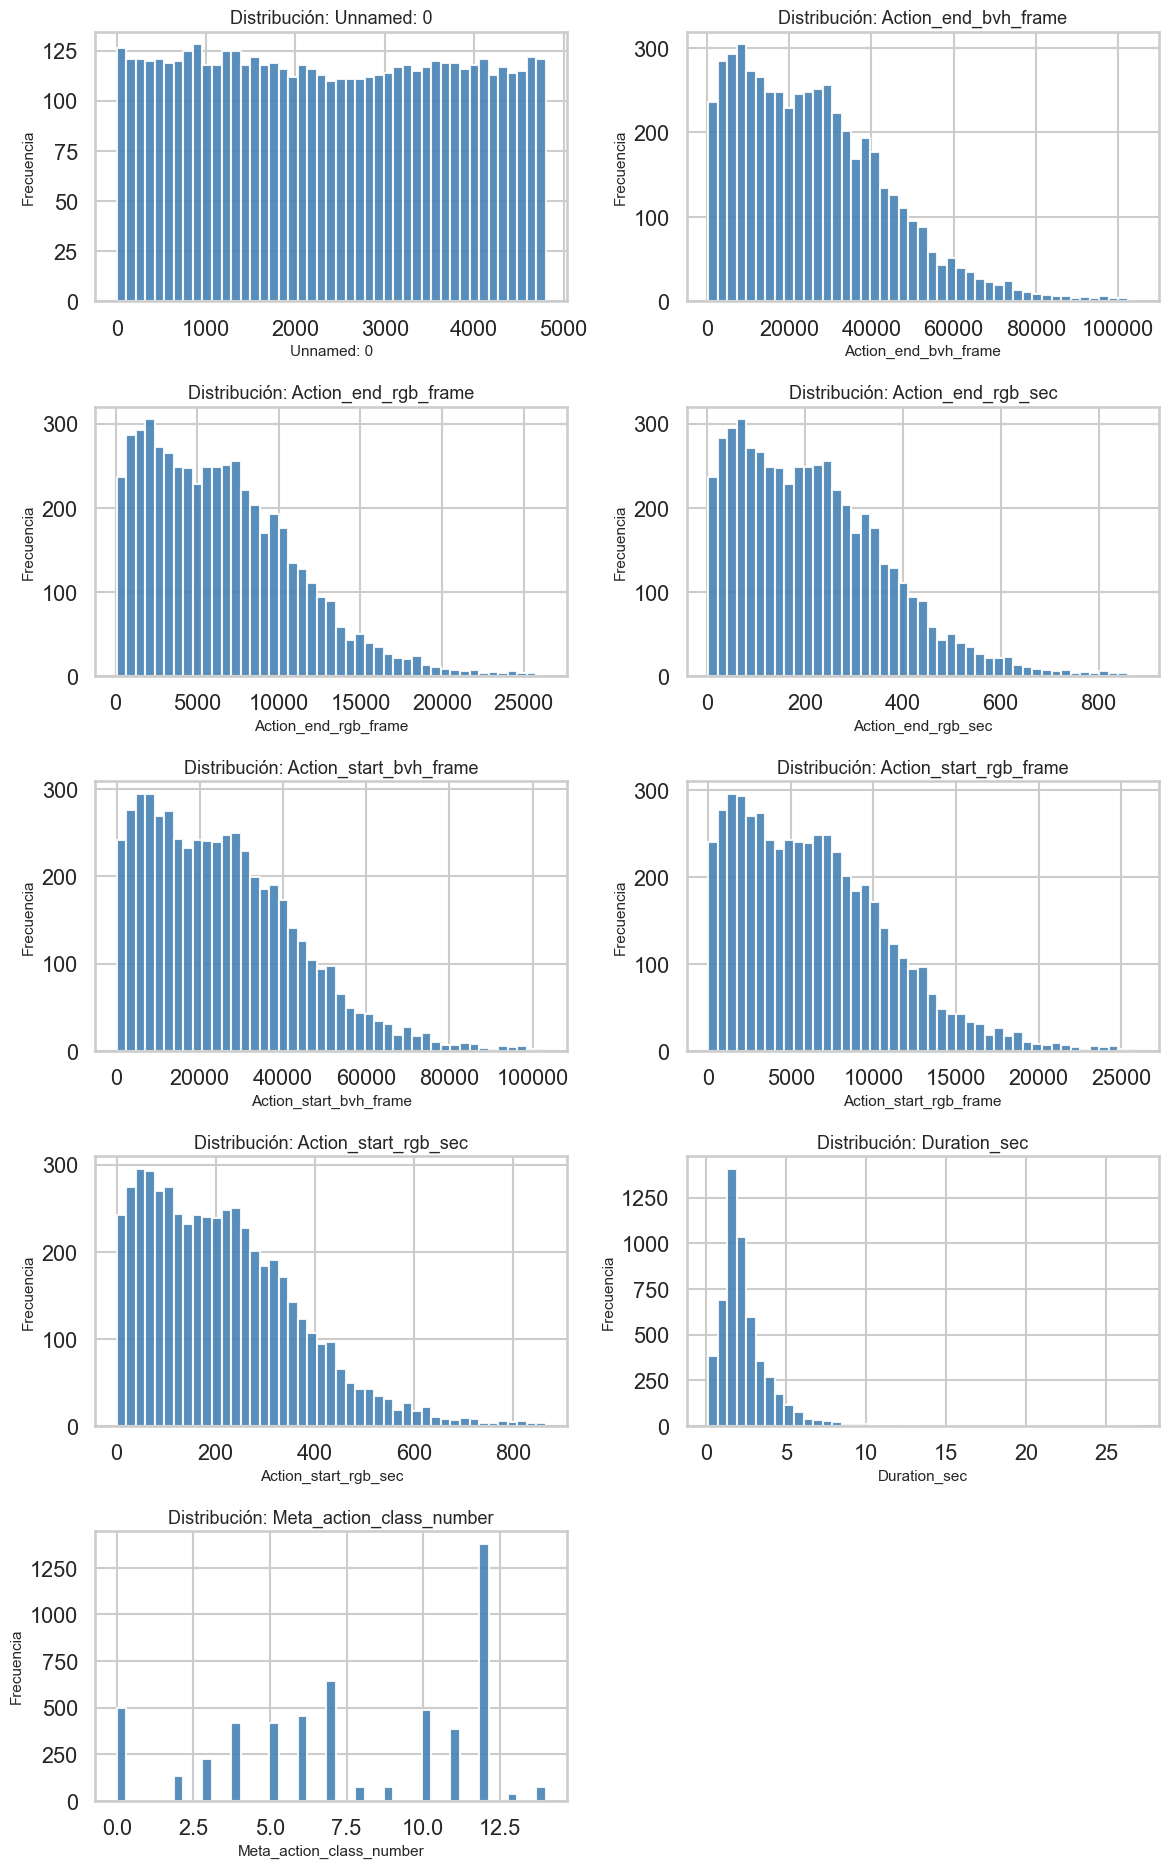

In [9]:
n = len(numeric_cols)
if n:
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.8 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, numeric_cols):
        s = df[col].dropna()
        bins = min(45, max(10, int(np.sqrt(len(s)))))
        ax.hist(s, bins=bins, color='steelblue', edgecolor='white', alpha=0.9)
        ax.set_title(f'Distribución: {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Frecuencia')
    for j in range(len(numeric_cols), len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print('Sin columnas numéricas.')


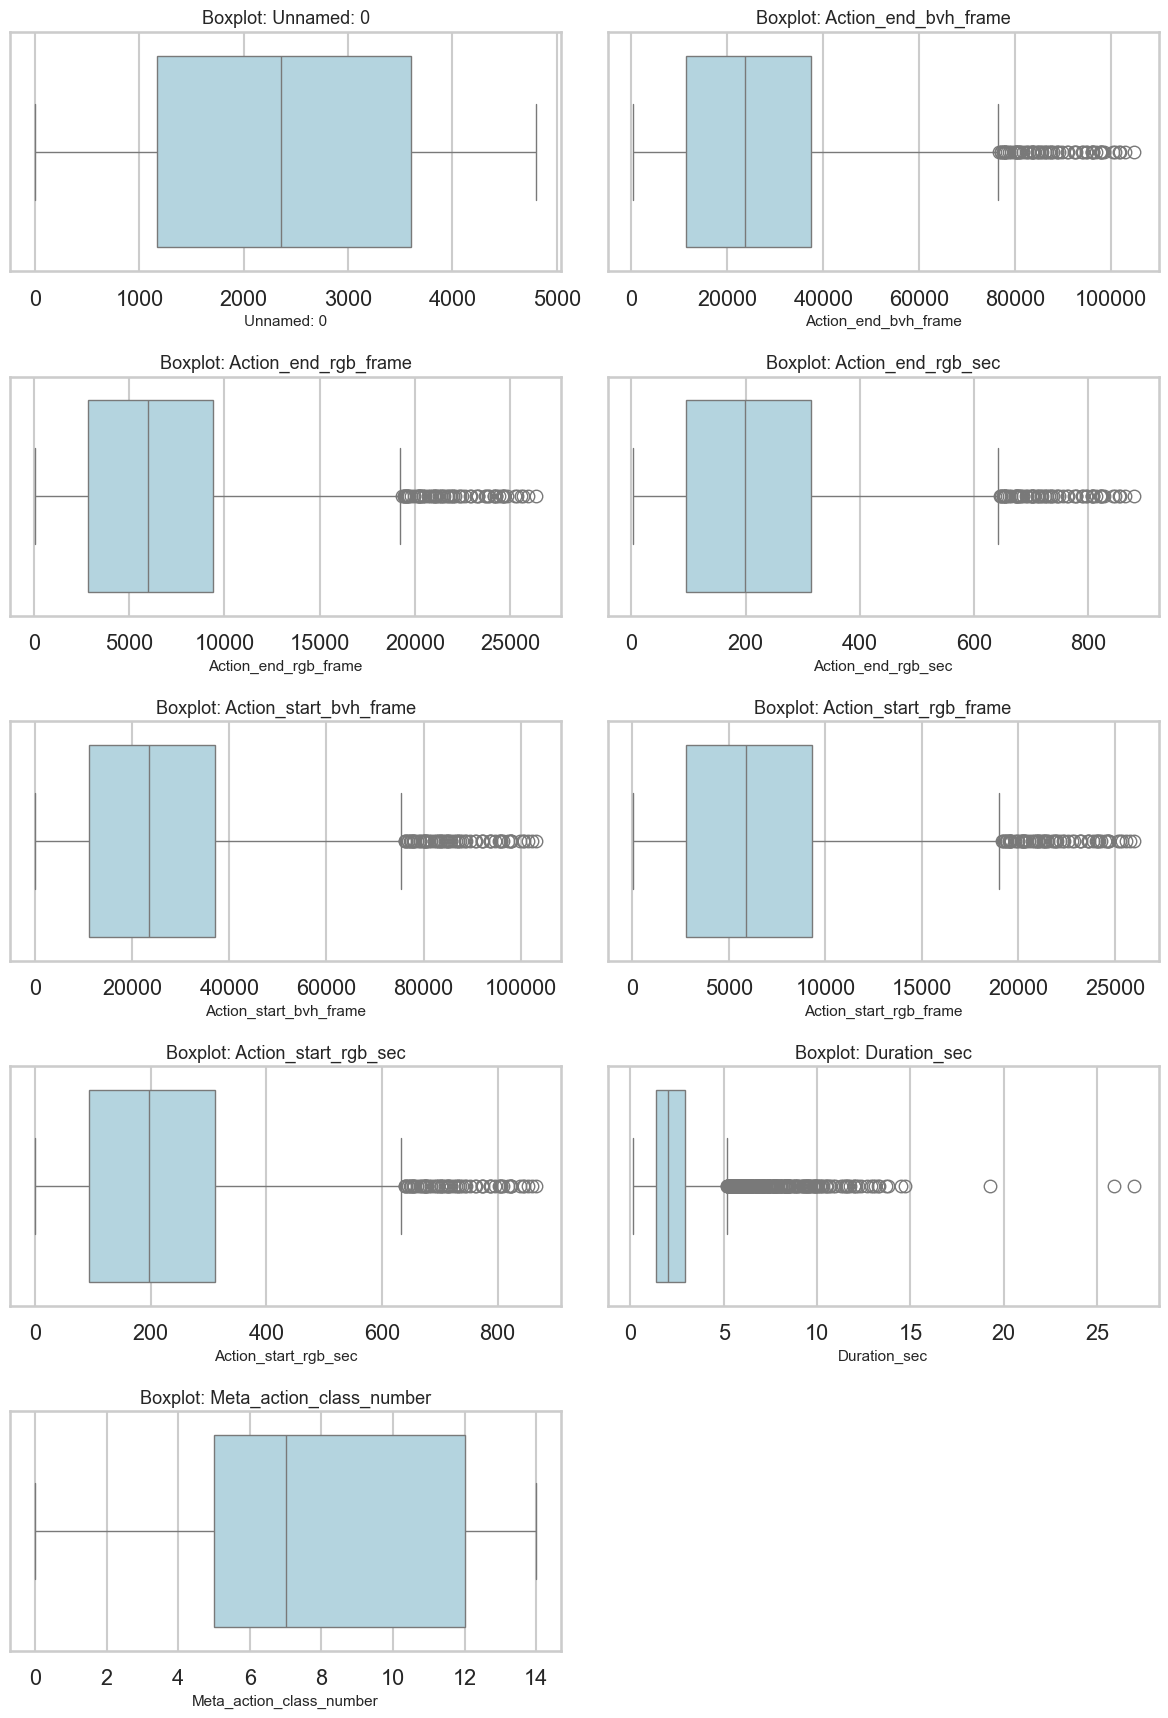

In [10]:
if numeric_cols:
    ncols = 2
    nrows = int(np.ceil(len(numeric_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.5 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, numeric_cols):
        sns.boxplot(x=df[col], ax=ax, color='lightblue')
        ax.set_title(f'Boxplot: {col}')
        ax.set_xlabel(col)
    for j in range(len(numeric_cols), len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()


,variable,n_categorias
0,Action_label,103
1,File,38
5,Subject,16
2,Meta_action_label,14
3,Operation,8
4,Recurrence,4


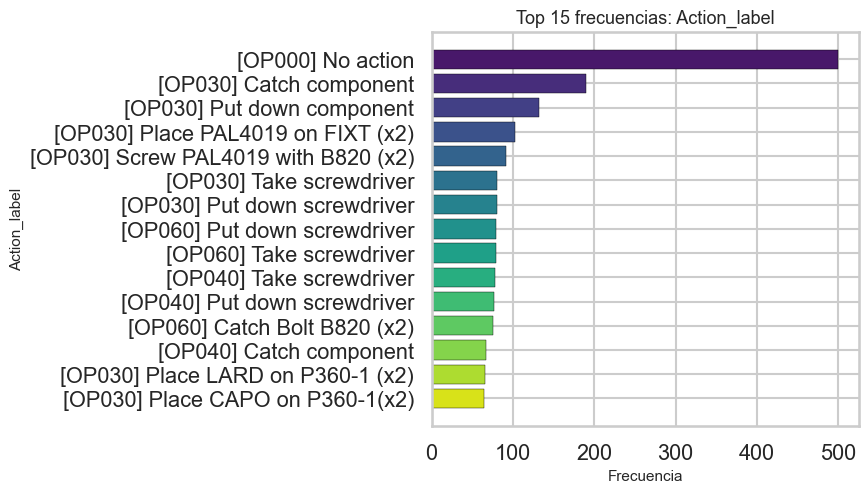

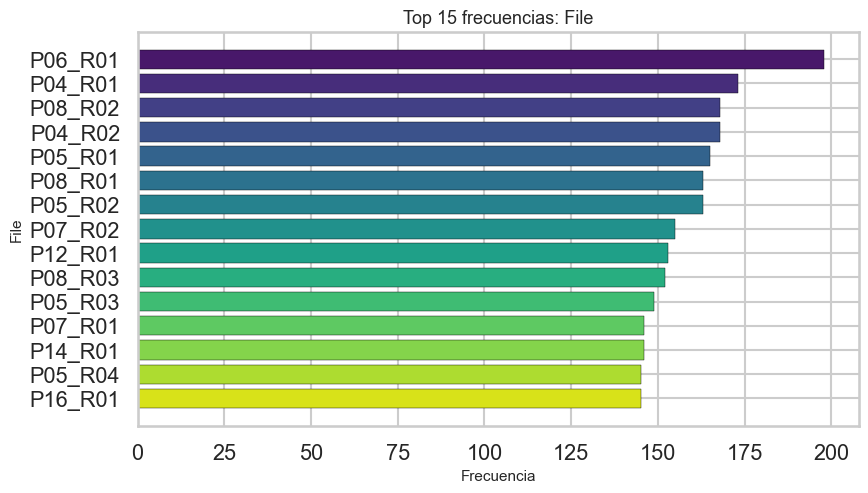

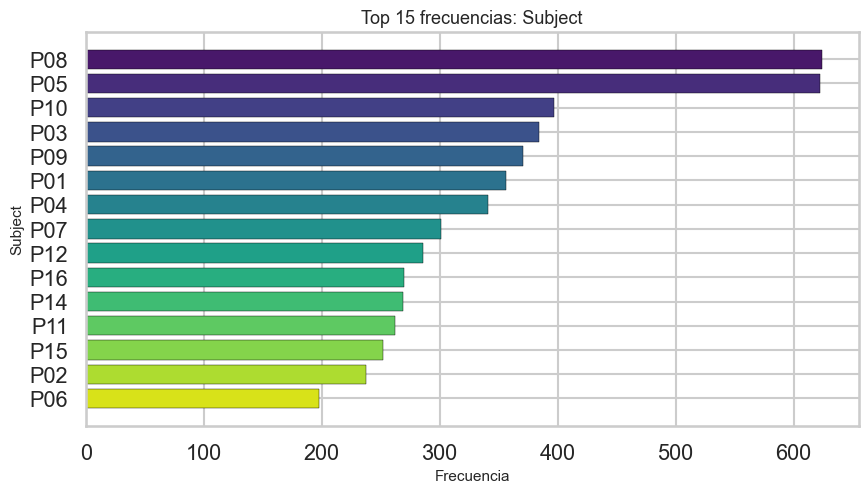

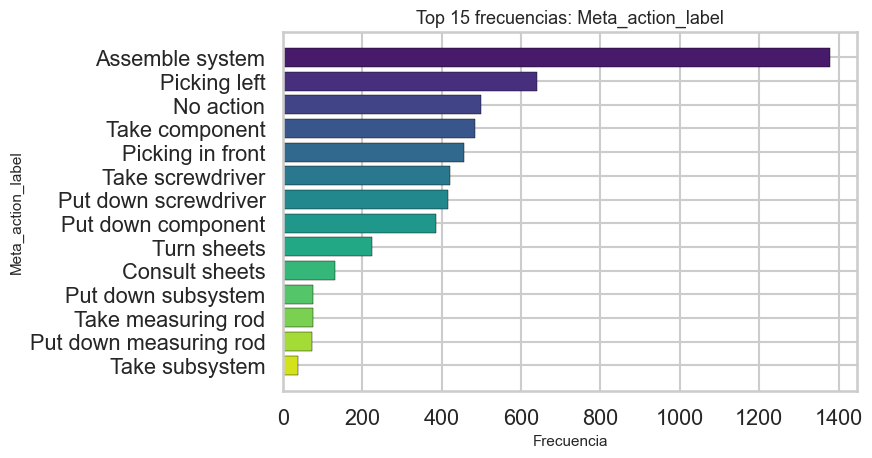

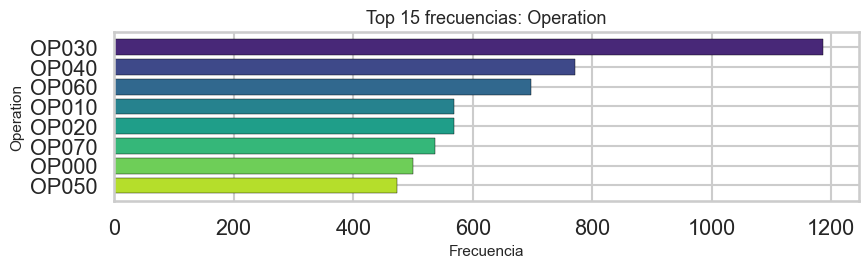

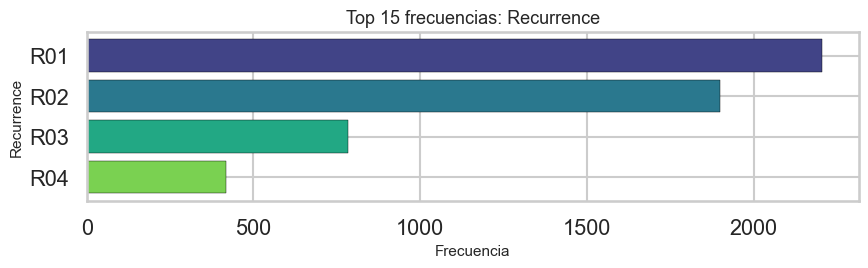

In [11]:
cardinalidad = []
for col in cat_cols:
    if col in df.columns:
        cardinalidad.append({'variable': col, 'n_categorias': df[col].astype(str).nunique()})
card_df = pd.DataFrame(cardinalidad).sort_values('n_categorias', ascending=False)
display(card_df)
TOP_K = 15
for col in card_df['variable']:
    vc = df[col].astype(str).value_counts().head(TOP_K)
    fig, ax = plt.subplots(figsize=(9, max(3, 0.35 * len(vc))))
    colors = sns.color_palette('viridis', n_colors=len(vc))
    ax.barh(vc.index.astype(str), vc.values, color=colors, edgecolor='black', linewidth=0.3)
    ax.invert_yaxis()
    ax.set_title(f'Top {TOP_K} frecuencias: {col}')
    ax.set_xlabel('Frecuencia')
    ax.set_ylabel(col)
    plt.tight_layout()
    plt.show()


## 4. Análisis bi y multivariante

**Por qué:** la **correlación** resume dependencias lineales entre numéricas; **pairplot** y gráficos vs **objetivo** exploran estructura conjunta y heterogeneidad entre clases.


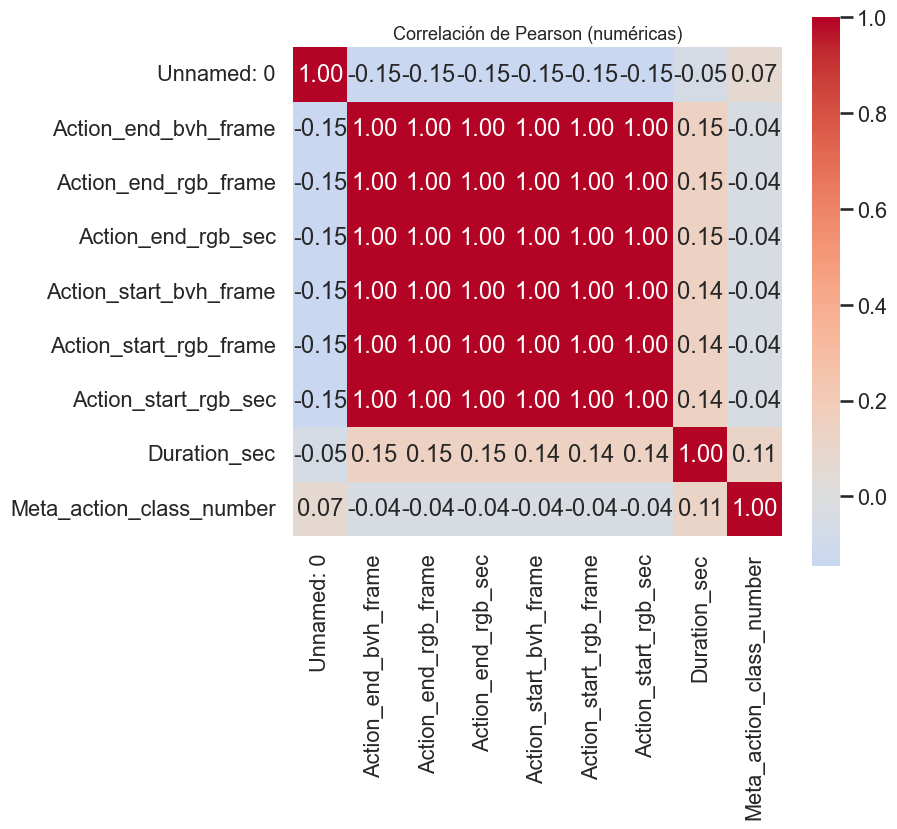

In [12]:
if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(1.05 * len(numeric_cols), 0.95 * len(numeric_cols)))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=ax)
    ax.set_title('Correlación de Pearson (numéricas)')
    plt.tight_layout()
    plt.show()
else:
    print('Se necesitan al menos 2 numéricas para heatmap.')


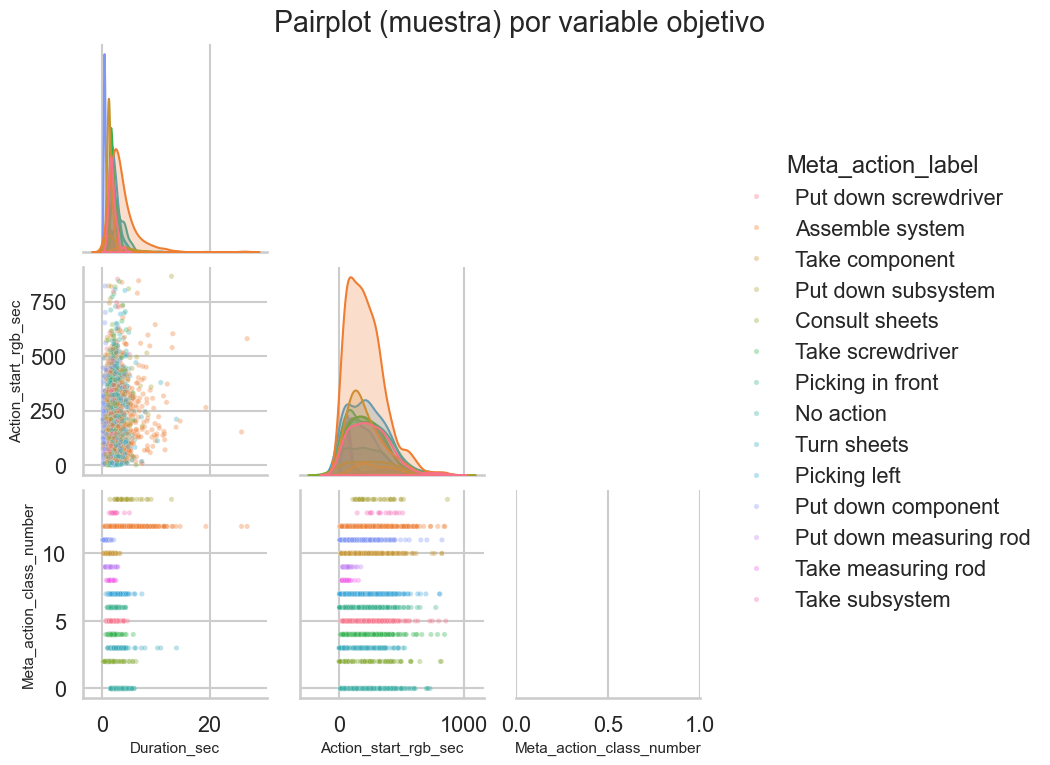

In [13]:
pair_cols = [c for c in ['Duration_sec', 'Action_start_rgb_sec', 'Meta_action_class_number'] if c in df.columns]
if len(pair_cols) >= 2 and VARIABLE_OBJETIVO in df.columns:
    muestra = df.sample(n=min(2500, len(df)), random_state=RANDOM_STATE)
    g = sns.pairplot(
        muestra,
        vars=pair_cols,
        hue=VARIABLE_OBJETIVO,
        corner=True,
        plot_kws={'alpha': 0.35, 's': 14},
        diag_kind='kde',
    )
    g.fig.suptitle('Pairplot (muestra) por variable objetivo', y=1.02)
    plt.show()
else:
    print('Pairplot omitido.')


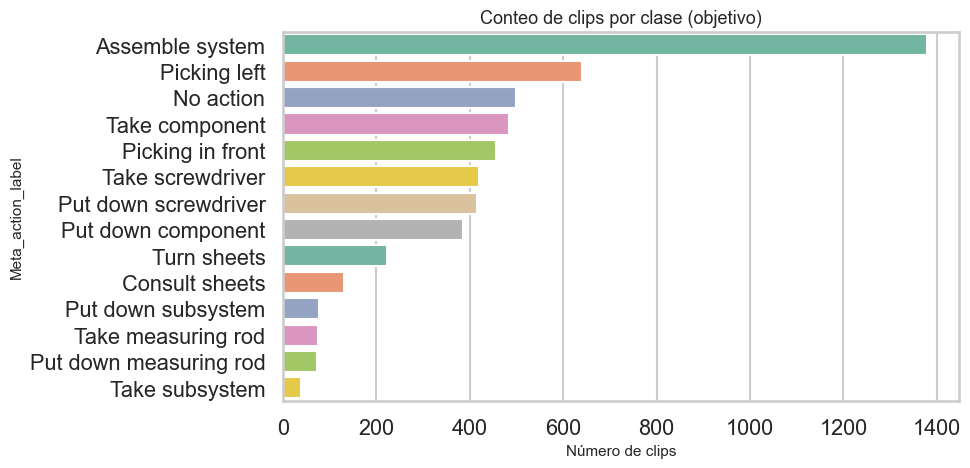

/var/folders/fc/52j9sv_132gdd2pvx3lpbt180000gn/T/ipykernel_8912/2044131750.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


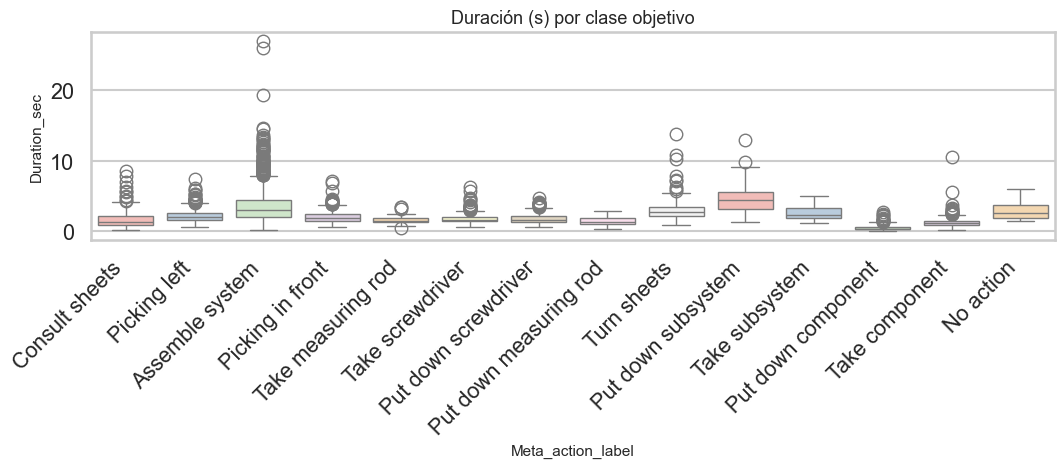

In [14]:
if VARIABLE_OBJETIVO in df.columns:
    orden = df[VARIABLE_OBJETIVO].value_counts().index
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.countplot(data=df, y=VARIABLE_OBJETIVO, order=orden, palette='Set2', ax=ax)
    ax.set_title('Conteo de clips por clase (objetivo)')
    ax.set_xlabel('Número de clips')
    ax.set_ylabel(VARIABLE_OBJETIVO)
    plt.tight_layout()
    plt.show()
if VARIABLE_OBJETIVO in df.columns and 'Duration_sec' in df.columns:
    fig, ax = plt.subplots(figsize=(11, 5))
    sns.boxplot(data=df, x=VARIABLE_OBJETIVO, y='Duration_sec', ax=ax, palette='Pastel1')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_title('Duración (s) por clase objetivo')
    ax.set_xlabel(VARIABLE_OBJETIVO)
    ax.set_ylabel('Duration_sec')
    plt.tight_layout()
    plt.show()


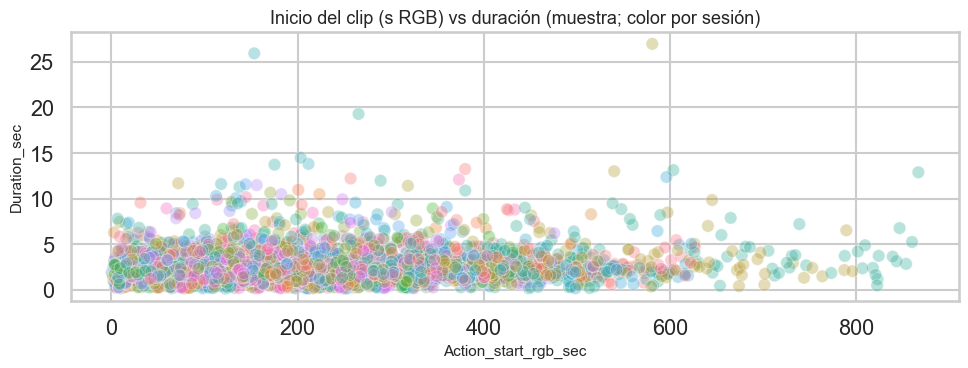

In [15]:
if 'Action_start_rgb_sec' in df.columns and 'Duration_sec' in df.columns:
    sub = df.sample(min(4000, len(df)), random_state=RANDOM_STATE)
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.scatterplot(data=sub, x='Action_start_rgb_sec', y='Duration_sec', hue='File', ax=ax, alpha=0.35, legend=False)
    ax.set_title('Inicio del clip (s RGB) vs duración (muestra; color por sesión)')
    ax.set_xlabel('Action_start_rgb_sec')
    ax.set_ylabel('Duration_sec')
    plt.tight_layout()
    plt.show()


## 5. Preprocesamiento justificado

**Por qué:** la rúbrica pide **justificar** imputación o eliminación de nulos, tratamiento de **atípicos** (IQR o Z-score) y **alta cardinalidad**. Se trabaja sobre `df_pp` sin perder el raw en `df`.


### 5.1 Valores faltantes

**Teoría:** si los nulos son pocos y aleatorios respecto a la etiqueta, **imputación** (mediana en numéricas, moda en categóricas) es aceptable. Si son muchos o sistemáticos, mejor **modelar la ausencia** o **excluir** la variable.


In [16]:
df_pp = df.copy()
for col in numeric_cols:
    if df_pp[col].isna().any():
        med = df_pp[col].median()
        df_pp[col] = df_pp[col].fillna(med)
        print(f'Imputado {col} con mediana={med}')
for col in cat_cols:
    if col in df_pp.columns and df_pp[col].isna().any():
        moda = df_pp[col].mode(dropna=True)
        v = moda.iloc[0] if len(moda) else 'DESCONOCIDO'
        df_pp[col] = df_pp[col].fillna(v)
        print(f'Imputado {col} con moda={v!r}')
print('Total nulos en df_pp:', int(df_pp.isna().sum().sum()))


Total nulos en df_pp: 0


### 5.2 Atípicos (IQR y Z-score)

**Teoría:** **IQR** es robusto a asimetría. **Z-score** asume forma cercana a la normal en la cola. En HAR, duraciones extremas pueden ser **válidas**; documentar si se **recortan** (p. ej. percentil 99) o se usan modelos **robustos**.


In [17]:
def mascara_iqr(serie: pd.Series, k: float = 1.5) -> pd.Series:
    s = serie.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return (serie < lo) | (serie > hi)


def mascara_z(serie: pd.Series, z: float = 3.0) -> pd.Series:
    mu, sig = serie.mean(), serie.std(ddof=0)
    if sig == 0 or np.isnan(sig):
        return pd.Series(False, index=serie.index)
    return ((serie - mu) / sig).abs() > z


if 'Duration_sec' in df_pp.columns:
    mi = mascara_iqr(df_pp['Duration_sec'])
    mz = mascara_z(df_pp['Duration_sec'])
    print('Outliers IQR Duration_sec:', int(mi.sum()), f'({100*mi.mean():.2f}%)')
    print('Outliers Z Duration_sec:', int(mz.sum()), f'({100*mz.mean():.2f}%)')
    p99 = df_pp['Duration_sec'].quantile(0.99)
    df_pp['Duration_sec_cap_p99'] = df_pp['Duration_sec'].clip(upper=p99)
    print('P99 Duration_sec:', float(p99))


Outliers IQR Duration_sec: 321 (6.05%)
Outliers Z Duration_sec: 103 (1.94%)
P99 Duration_sec: 9.359199999999982


### 5.3 Alta cardinalidad en `Action_label`

**Teoría:** categorías raras inflan dimensionalidad y varianza del estimador; **agrupar en "Otros"** o **encoding por frecuencia** estabiliza el modelo (con cuidado de no filtrar información del test).


In [18]:
COL = 'Action_label'
UMBRAL = 5
if COL in df_pp.columns:
    freq = df_pp[COL].value_counts()
    raras = freq[freq <= UMBRAL].index
    df_pp['Action_label_agrupada'] = np.where(
        df_pp[COL].isin(raras),
        'Otros (baja frecuencia)',
        df_pp[COL],
    )
    print('Cardinalidad antes:', df_pp[COL].nunique())
    print('Cardinalidad después:', df_pp['Action_label_agrupada'].nunique())
    display(df_pp['Action_label_agrupada'].value_counts().head(12))
else:
    print('Sin columna Action_label.')


Cardinalidad antes: 103
Cardinalidad después: 103


Action_label_agrupada
[OP000] No action                       500
[OP030] Catch component                 190
[OP030] Put down component              132
[OP030] Place PAL4019 on FIXT (x2)      102
[OP030] Screw PAL4019 with B820 (x2)     91
[OP030] Take screwdriver                 80
[OP030] Put down screwdriver             80
[OP060] Put down screwdriver             79
[OP060] Take screwdriver                 79
[OP040] Take screwdriver                 78
[OP040] Put down screwdriver             77
[OP060] Catch Bolt B820 (x2)             76
Name: count, dtype: int64

## 6. Conclusiones (respuestas a la rúbrica y preguntas guía)

### ¿Hay valores faltantes? ¿Patrones?

En el CSV segmentado típico de InHARD **casi no hay nulos**; la celda de auditoría lo confirma. Si en otra versión aparecieran, habría que estudiar si dependen de `Operation` o `Subject`.

### ¿Estadísticas resumidas?

Cubiertas con `describe` numérico y categórico más `info`.

### ¿Valores atípicos?

Sí en **`Duration_sec`** (colas); no siempre deben eliminarse. Opción documentada: **`Duration_sec_cap_p99`**.

### ¿Cardinalidad?

Revisar `card_df`; **`Action_label`** suele ser de **alta cardinalidad** frente a **`Meta_action_label`**.

### ¿Sesgo en distribuciones?

Las **duraciones** suelen ser **asimétricas positivas**. Las **clases** están **desequilibradas** hacia meta-acciones de ensamblaje y picking.

### ¿Transformaciones recomendadas?

- **Clasificación:** `class_weight`, muestreo, o F1 macro; **validación por `File`**.
- **Numéricas:** `RobustScaler` o `StandardScaler` según outliers.
- **Duración:** opcional `log1p` si el modelo lo requiere.
- **Acción fina:** usar `Action_label_agrupada` o embeddings.

### ¿Tendencias temporales?

El índice tiene **`Action_start_rgb_sec`** dentro de cada sesión; el scatter da intuición de dispersión, no una serie completa del video.

### ¿Correlación con la objetivo categórica?

Pearson no aplica directo; se usó **conteo** y **boxplot de duración por clase**.

### ¿Normalizar imágenes?

Para **RGB** en fases posteriores: normalizar a **[0,1]** o por estadísticas de **train**; esta libreta es **tabular**.

### ¿Desequilibrio de clases?

**Sí** en `Meta_action_label`; reportar en el informe y ajustar métricas y muestreo.

### ¿Sesgos del conjunto?

Sesgo de **muestreo por clase** y posible **sesgo por sujeto/sesión**; mitigar con **split por sesión** y reportar composición por `Subject`.

---

**Cierre:** el equipo debe **revisar figuras**, **completar** hallazgos específicos del CSV usado y **verificar ejecución secuencial** antes de entregar la liga en GitHub.
